(density-estimator)=

# 密度的估计

在给定若干粒子的三维坐标及其对应质量的情况下，如何估计任意位置处的质量密度？

常见的方法包括 Tessellation 方法（如 Voronoi 和 Delaunay等），平滑粒子密度估计（SPH）等。这些方法在粒子质量扩散的形状、范围等方面各有特点。

在这些方法中，SPH 方法兼顾了计算效率和精度，因此在 ``Gal3D`` 中采用了平滑粒子法（SPH），也称为自适应核密度估计（adaptive KDE）。SPH 方法通过核函数（kernel function）将点粒子的质量扩散为连续的质量密度分布。


## SPH 的密度估计

``Gal3D`` 默认使用 Cubic Spline 核函数: $W(\mathbf{r}, h) = w(\dfrac{r}{h})$，该核函数的具体表达式为：

$$
    w(u) = \frac{8}{\pi} \begin{cases}
        1 - 6 (u)^{2} + 6 (u)^{3}, & 0 \le u \le \tfrac{1}{2},\\[6pt]
        2 \left(1 - u\right)^{3}, & \tfrac{1}{2} < u \le 1,\\[6pt]
        0, & \text{otherwise.}
    \end{cases}
$$
    
并满足归一化条件：

$$
    4 \pi  \int_{0}^{\infty} w(u) u^{2} \mathrm{d}u = 1.
$$

其中， $h$ 是 SPH 方法中的一个关键参数，决定了粒子影响范围的大小。如果 $h$ 过大，密度场会过于平滑，无法捕捉粒子间的细微结构；如如果 $h$ 过小，则可能导致密度场出现噪声。因此，选择合适的 $h$ 值对于 SPH 方法的效果十分重要。


在 ``Gal3D`` 中，定义每个粒子的 $h$ 值被定义为其到第 $k$ 个最近邻粒子的距离。这样可以确保在不同的局部密度环境中，粒子的 $h$ 值能够自适应地调整，从而提高密度估计的稳定性。

为了实现近邻搜索，``Gal3D`` 使用了 [scipy.spatial.KDTree](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.KDTree.html#scipy.spatial.KDTree)。默认情况下，``Gal3D`` 设置 ``k=32`` ，用于确定粒子邻域和 $h$ 值。
对于任意位置的密度 $\rho_i$，通过搜索 $k$ 个近邻粒子，其密度估计公式为：

$$
    \rho_i = \sum_{j=1}^{k} m_{j} W(\mathbf{r}_{i} - \mathbf{r}_{j}, h_{i})
$$

(SPH-render2d)=

## SPH 投影

在 ``Gal3D`` 中，SPH 投影采用了 Cubic Spline 核函数的投影公式 $\Sigma(\dfrac{R}{h})$，其表达式为：

$$
    \Sigma(q) = \dfrac{2}{\pi}
    \begin{cases}
        (4 + 26q^2)\sqrt{1-q^2} - (1 + 26q^2)\sqrt{1-4q^2} \\
        \qquad - 18q^4 \ln\left(\dfrac{2q}{1+\sqrt{1-4q^2}}\right)
        - 6q^2(4+q^2)\ln\left(\dfrac{2+2\sqrt{1-q^2}}{1+\sqrt{1-4q^2}}\right)
        & 0 \leq q \leq \tfrac{1}{2}, \\[12pt]
        2(2 + 13q^2)\sqrt{1-q^2} + 6q^2(4+q^2)\ln\left(\dfrac{q}{1+\sqrt{1-q^2}}\right)
        & \tfrac{1}{2} < q \leq 1, \\[12pt]
        0 & \text{otherwise.}
    \end{cases}
$$

并满足归一化条件：

$$
    2 \pi  \int_{0}^{\infty} \Sigma(q) q \mathrm{d}q = 1.
$$

对于给定的二维网格，粒子的质量通过投影的核函数分布到网格中。对于粒子尺寸 $\lesssim$ 网格尺寸的情况，采用了 [粒子二次采样](https://arxiv.org/abs/2106.05281) 的方法减少误差。同时，为了保证投影的质量守恒，每个粒子的质量分配都会重新归一化。

下图展示了单个粒子（红色点及其对应的红色圆圈）在给定网格上的质量分布，并通过二次采样方法提高精度的示例。

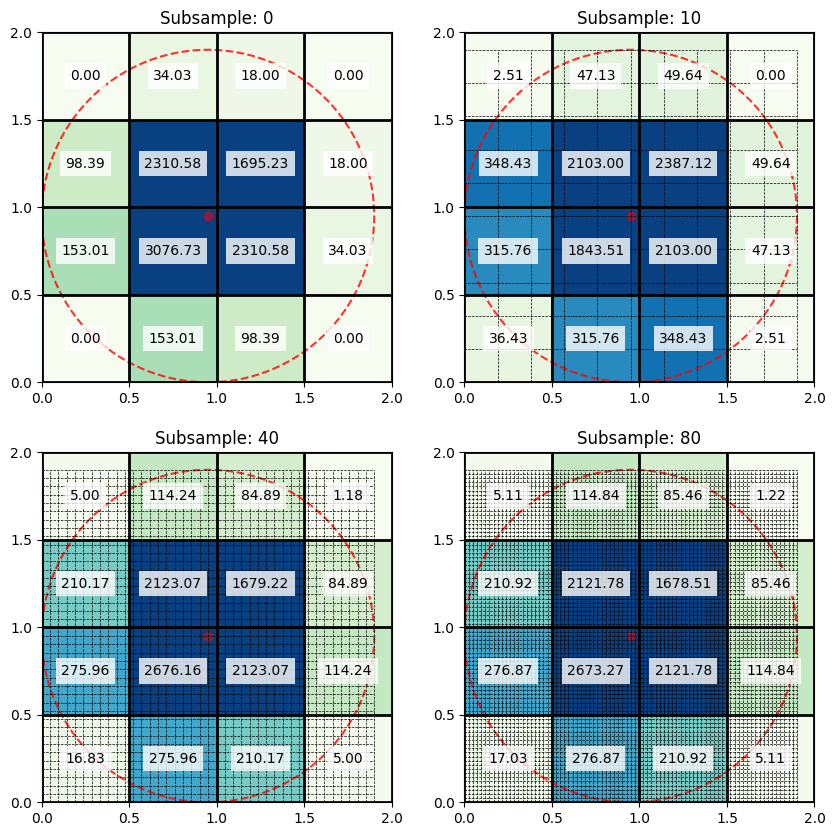

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np
from gal3d.visualization.hist2d import render_2d
from gal3d.visualization.show import show_image


pos = np.array([[0.95,0.95,0]])
mass = np.array([1e4])
hsm = np.array([0.95])

region = [0,2]
nbins = 4

vmin = 0.4
vmax = mass/6

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

subsample_lin = [0, 10, 40, 80]

for idx, subsample in enumerate(subsample_lin):
    row, col = divmod(idx, 2)
    ax = axes[row, col]

    # sph render
    im = render_2d(pos,mass,hsm,x_range=region,y_range=region,nbins=nbins,subsample=subsample)
    show_image(im,axesObj=ax, cmap="GnBu",vmin=vmin,vmax=vmax,logscale=False)

    # particle region
    circle = Circle(pos[0][:2], hsm[0], color='r', fill=False, linewidth=1.5,alpha=0.8,linestyle="--")
    ax.add_patch(circle)
    ax.scatter(pos[0][0], pos[0][1],color='r', alpha=0.5)

    # subsample grid
    if subsample > 0 :
        cell_size = 2 * hsm[0] / subsample 
        for i in range(subsample + 1):
            ax.plot(
                [pos[0][0] - hsm[0], pos[0][0] + hsm[0]], 
                [pos[0][1] - hsm[0] + i * cell_size] * 2, 
                color='k', linestyle='--', linewidth=0.5
            )
            ax.plot(
                [pos[0][0] - hsm[0] + i * cell_size] * 2, 
                [pos[0][1] - hsm[0], pos[0][1] + hsm[0]],
                color='k', linestyle='--', linewidth=0.5
            )

    # values
    for i, x in enumerate(im.xs):
        for j, y in enumerate(im.ys):
            value = im.value[j, i]*im.pixel_area
            ax.text(x, y, f'{value:.2f}', color='black', fontsize=10, ha='center', va='center',bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))

    # main grid
    ax.set_xticks([0,0.5,1,1.5,2],)
    ax.set_yticks([0,0.5,1,1.5,2])
    ax.grid(True, linestyle='solid',color='k', linewidth=2)
    ax.set_title(f'Subsample: {subsample}')

## 示例

以下是一个示例，随机生成 10000 个粒子，赋予它们随机的三维坐标和质量，并将总质量归一化为 $10^8$：

In [2]:
import numpy as np
from gal3d.point import Particles

npart = 10000
mtol = 1e8
np.random.seed(42)
pos = np.cos(2*np.pi*np.sin(np.random.random((npart,3))*2*np.pi)**2/np.cos(np.sin(np.random.random((npart,3))*2*np.pi)**2))
mass = np.random.random(npart)
mass = mtol*mass/np.sum(mass)

接下来，展示不同近邻数量 $k$ 和投影网格数量 $nbins$ 对粒子分布投影结果的影响。从左到右分别表示 $k$ 的变化（4, 16, 32, 64, 128），从上到下表示 $nbins$ 的变化（8, 32, 128, 512, 1024）。随着 $k$ 增大，$h$ 的值也随之增大，粒子在空间中的影响范围变得更广，投影结果的平滑程度提高。此外，投影后的总质量与真实总质量的差异几乎可以忽略（$\Delta M / M_{tot} \lesssim 10^{-5}$）。

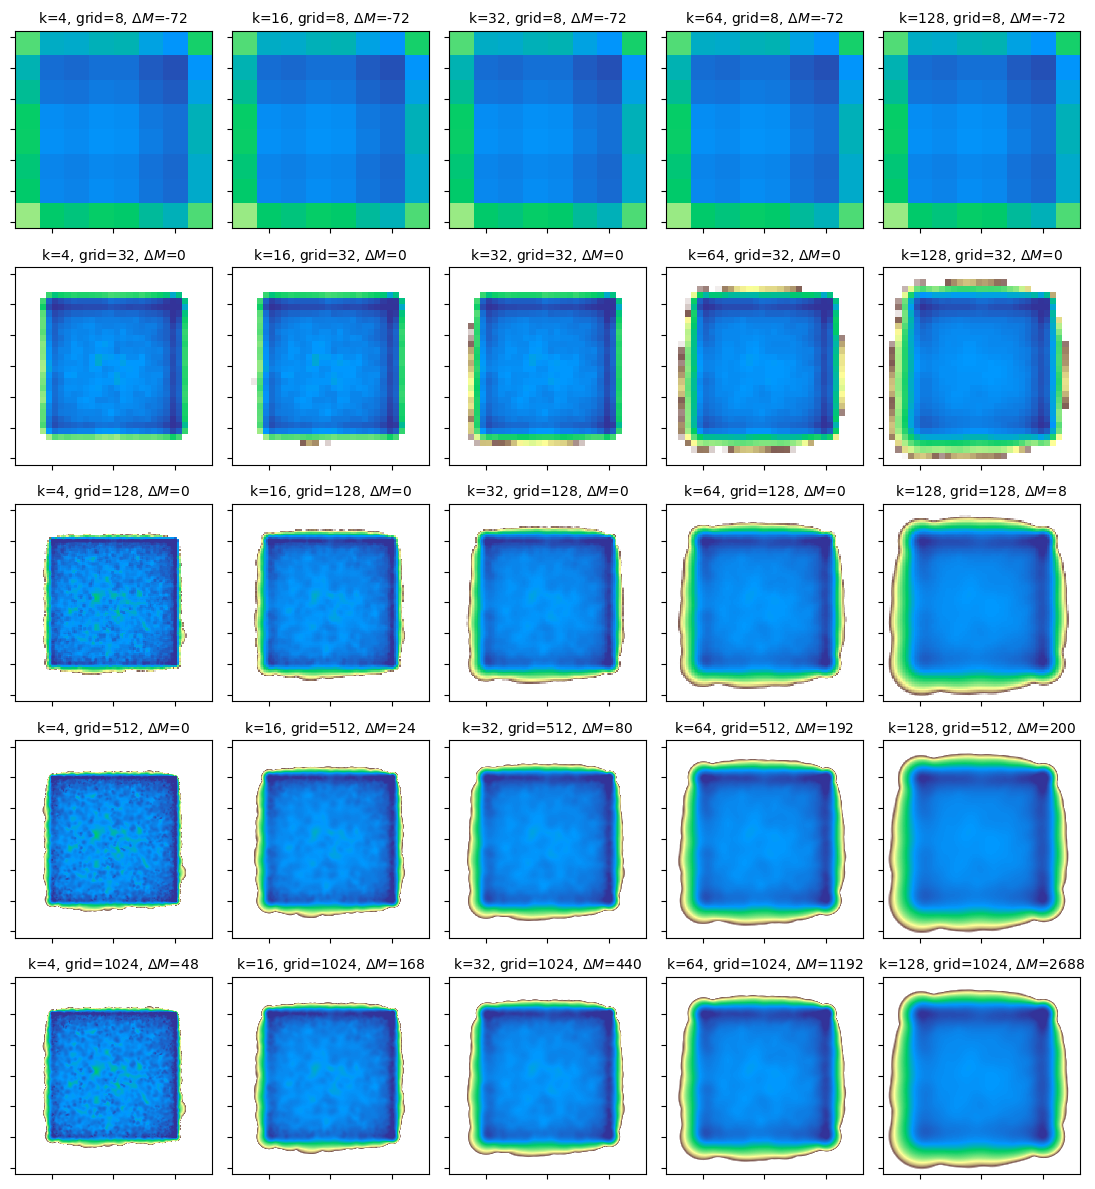

In [3]:
import matplotlib.pyplot as plt
from gal3d.visualization.show import show_image
from gal3d.point import Particles

k_num = [4, 16, 32, 64, 128]
nbins = [8, 32, 128, 512, 1024]
ed = 1.6
fig, axes = plt.subplots(len(nbins), len(k_num), figsize=(11, 12))
for i, bins in enumerate(nbins):
    for j, k in enumerate(k_num):
        particle = Particles(pos=pos, mass=mass, recenter=False, estimator_kwargs={'k': k})
        hsm = particle.hsm
        ax = axes[i, j]
        im = particle.project_2d(x_range=[-ed,ed], y_range=[-ed,ed],resolution=bins,render_by="sph")
        show_image(im, axesObj=ax, cmap='terrain_r', vmin=1, vmax=mtol)
        ax.set_title(f'k={k}, grid={bins}, '+"$\Delta M$="+f"{im.total_quantity-mtol:.0f}", fontsize=10)
        ax.set_xticklabels([])
        ax.set_yticklabels([])
plt.subplots_adjust(wspace=0, hspace=0)
plt.tight_layout()
plt.show()

通过调整 `config`中的设置，将`render_double`设置为`True`，可以进一步提高数值精度，减少误差：

In [4]:
from gal3d.configuration import config
config.sph_render.render_double = True

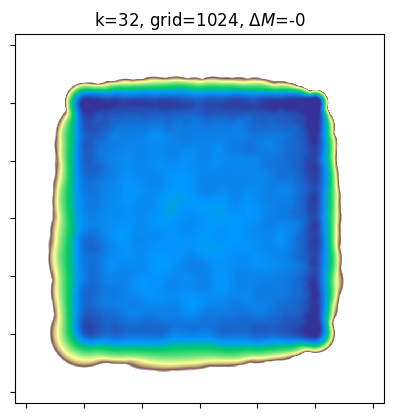

In [5]:
k=32
bins = 1024
particle = Particles(pos=pos, mass=mass, recenter=False, estimator_kwargs={'k': k})
hsm = particle.hsm
im = render_2d(pos, mass, hsm, x_range=[-ed,ed], y_range=[-ed,ed], nbins=bins)
ax = show_image(im,cmap='terrain_r', vmin=1, vmax=mtol)
ax.axes.set_title(f'k={k}, grid={bins}, '+"$\Delta M$="+f"{im.total_quantity-mtol:.0f}")
ax.axes.set_xticklabels([])
ax.axes.set_yticklabels([])
plt.show()